# Classificador Multi-Classe SOME/IP IDS

Comparação entre abordagem **One-vs-Rest (OvR)** com 4 classificadores binários e um único classificador **multi-classe (5 classes)** baseado em XGBoost.

**Classes:**
| Label | Classe       | Descrição |
|-------|-------------|----------|
| 0     | Benigno      | Tráfego normal |
| 1     | DoS          | Flood de notificações |
| 2     | Fuzzy        | SD offer flood + payloads aleatórios |
| 3     | MITM_Multi   | Relay + spoofing SD + ADAS forjado |
| 4     | MITM_Single  | SD withdraw + ADAS forjado |

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

DATA_DIR  = Path('data')
MODEL_DIR = Path('model')

with open(MODEL_DIR / 'results.json') as f:
    results = json.load(f)

with open(DATA_DIR / 'class_counts.json') as f:
    class_counts = json.load(f)

CLASS_NAMES = ['Benigno', 'DoS', 'Fuzzy', 'MITM_Multi', 'MITM_Single']
print('Resultados carregados.')

Resultados carregados.


## 1. Distribuição do Dataset

Total de amostras: 3,848,801

Classe                      N   % total
----------------------------------------
Benigno             2,193,802     57.0%
DoS                   306,944      8.0%
Fuzzy                 560,052     14.6%
MITM_Multi            427,493     11.1%
MITM_Single           360,510      9.4%


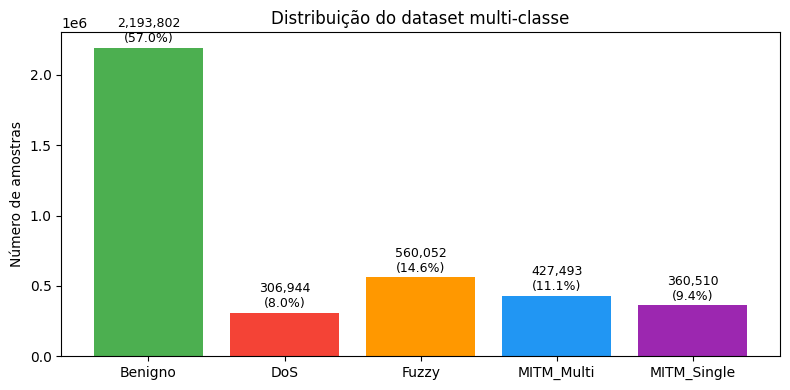

In [2]:
total = sum(class_counts.values())
print(f'Total de amostras: {total:,}\n')
print(f'{"Classe":<15}  {"N":>12}  {"% total":>8}')
print('-' * 40)
for name, n in class_counts.items():
    print(f'{name:<15}  {n:>12,}  {100*n/total:>7.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']
bars = ax.bar(CLASS_NAMES, [class_counts[n] for n in CLASS_NAMES], color=colors)
ax.set_ylabel('Número de amostras')
ax.set_title('Distribuição do dataset multi-classe')
for bar, n in zip(bars, CLASS_NAMES):
    v = class_counts[n]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'{v:,}\n({100*v/total:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150)
plt.show()

## 2. Resultados Globais

In [3]:
print('=' * 55)
print('  CLASSIFICADOR MULTI-CLASSE — Resultados Globais')
print('=' * 55)
print(f'  Acurácia global  : {results["accuracy"]:.4f}')
print(f'  F1 macro         : {results["f1_macro"]:.4f}')
print(f'  F1 weighted      : {results["f1_weighted"]:.4f}')
print(f'  Tempo treino     : {results["t_train_s"]:.1f}s')
print(f'  Latência/pacote  : {results["t_single_ms"]:.3f} ms')
print(f'  Throughput       : {results["throughput_pkt_s"]:,.0f} pkt/s')

  CLASSIFICADOR MULTI-CLASSE — Resultados Globais
  Acurácia global  : 0.9994
  F1 macro         : 0.9993
  F1 weighted      : 0.9994
  Tempo treino     : 95.3s
  Latência/pacote  : 1.097 ms
  Throughput       : 171,005 pkt/s


## 3. Comparação OvR vs Multi-Classe por Classe

  Classe             F1 Multi      F1 OvR     Delta
  --------------------------------------------------
  Benigno              0.9995         N/A       N/A
  DoS                  0.9999      0.9998   +0.0001
  Fuzzy                0.9996      0.9990   +0.0006
  MITM_Multi           0.9982      0.9979   +0.0003
  MITM_Single          0.9994      0.9994   +0.0000


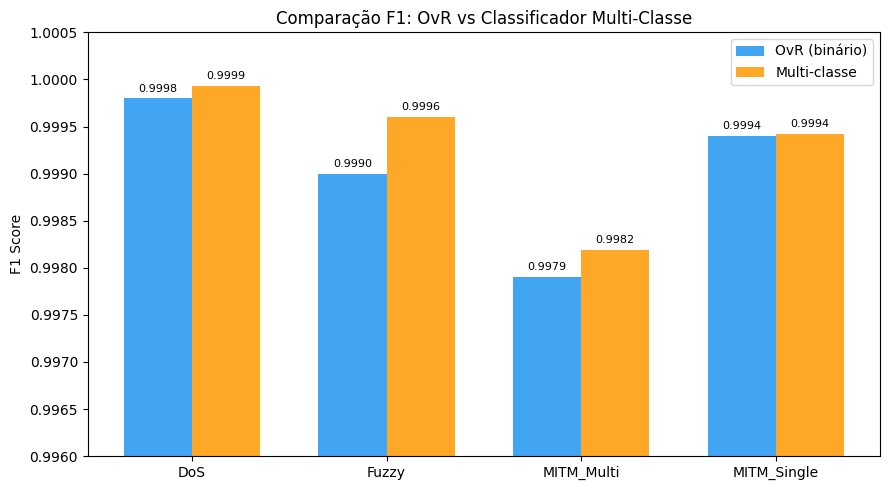

In [4]:
ovr_f1 = results['ovr_f1']
multi_f1 = results['f1_per_class']

print(f'  {"Classe":<15}  {"F1 Multi":>10}  {"F1 OvR":>10}  {"Delta":>8}')
print('  ' + '-' * 50)
for name in CLASS_NAMES:
    m = multi_f1[name]
    o = ovr_f1.get(name)
    if o:
        delta = f'{m - o:+.4f}'
    else:
        delta = '   N/A'
    o_str = f'{o:.4f}' if o else '   N/A'
    print(f'  {name:<15}  {m:>10.4f}  {o_str:>10}  {delta:>8}')

# Gráfico de barras agrupadas
attack_names = ['DoS', 'Fuzzy', 'MITM_Multi', 'MITM_Single']
ovr_vals   = [ovr_f1[n] for n in attack_names]
multi_vals = [multi_f1[n] for n in attack_names]

x = np.arange(len(attack_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, ovr_vals,   width, label='OvR (binário)', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, multi_vals, width, label='Multi-classe',  color='#FF9800', alpha=0.85)

ax.set_ylabel('F1 Score')
ax.set_title('Comparação F1: OvR vs Classificador Multi-Classe')
ax.set_xticks(x)
ax.set_xticklabels(attack_names)
ax.set_ylim(0.996, 1.0005)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

## 4. Matriz de Confusão

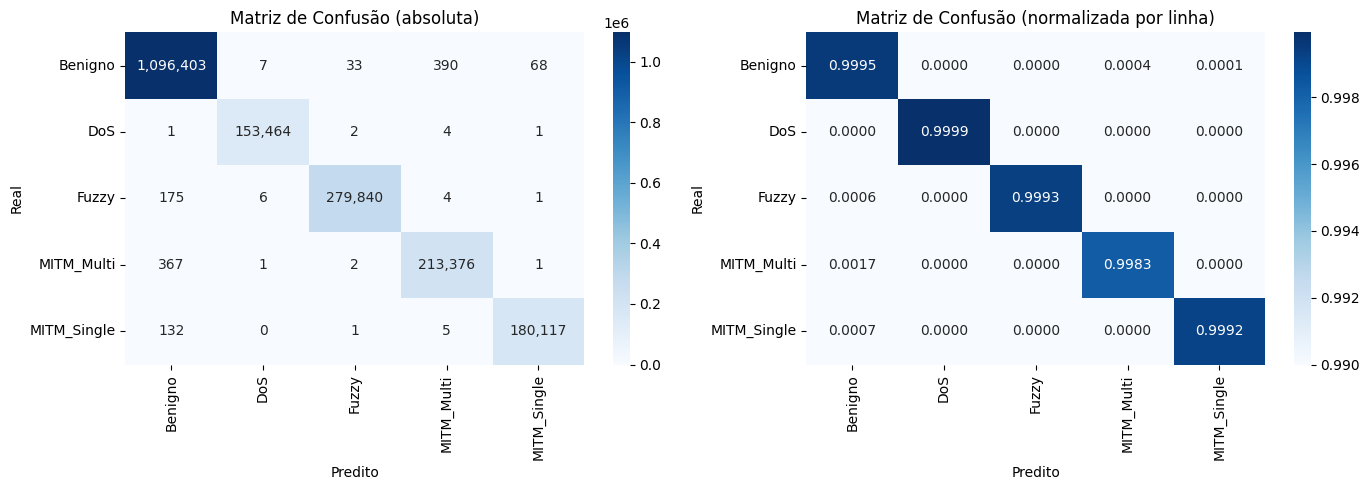


Erros por classe:
Classe                 FP        FN         Total
--------------------------------------------------
Benigno               675       498     1,096,901
DoS                    14         8       153,472
Fuzzy                  38       186       280,026
MITM_Multi            403       371       213,747
MITM_Single            71       138       180,255


In [5]:
cm = np.array(results['confusion_matrix'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
ax = axes[0]
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Matriz de Confusão (absoluta)')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')

# Normalizada por linha
ax = axes[1]
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
            vmin=0.99)
ax.set_title('Matriz de Confusão (normalizada por linha)')
ax.set_ylabel('Real')
ax.set_xlabel('Predito')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Erros por classe
print('\nErros por classe:')
print(f'{"Classe":<15}  {"FP":>8}  {"FN":>8}  {"Total":>12}')
print('-' * 50)
for i, name in enumerate(CLASS_NAMES):
    fn = cm[i].sum() - cm[i, i]  # falso negativo: real=i, pred!=i
    fp = cm[:, i].sum() - cm[i, i]  # falso positivo: real!=i, pred=i
    print(f'{name:<15}  {fp:>8,}  {fn:>8,}  {cm[i].sum():>12,}')

## 5. Importância das Features

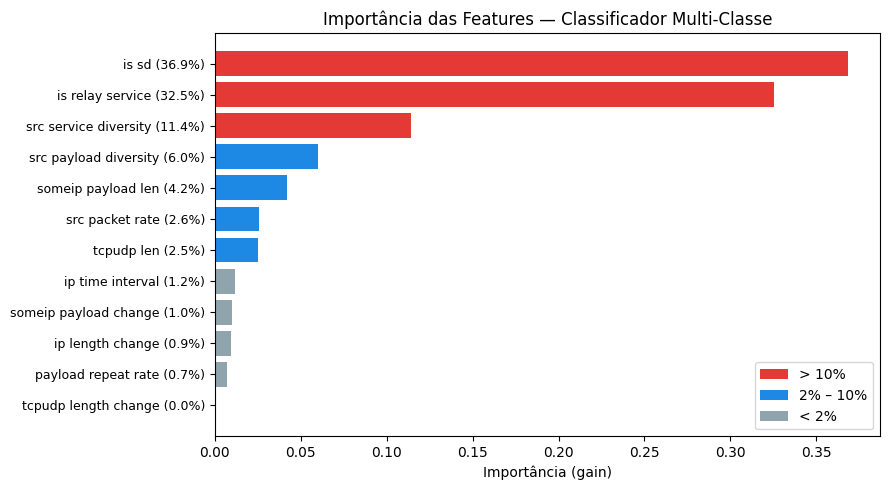

In [6]:
import xgboost as xgb

FEAT_COLS = [
    'f01_ip_time_interval', 'f08_someip_payload_change',
    'f11_ip_length_change', 'f12_tcpudp_length_change',
    'f13_payload_repeat_rate', 'f15_someip_payload_len',
    'f16_tcpudp_len', 'f17_src_packet_rate', 'f18_src_payload_diversity',
    'f19_is_sd', 'f20_src_service_diversity', 'f21_is_relay_service',
]

model = xgb.XGBClassifier()
model.load_model(str(MODEL_DIR / 'multiclass_classifier.json'))

importances = model.feature_importances_
pairs = sorted(zip(FEAT_COLS, importances), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(9, 5))
names, vals = zip(*pairs)
short_names = [n.split('_', 1)[1].replace('_', ' ') for n in names]
colors = ['#E53935' if v > 0.1 else '#1E88E5' if v > 0.02 else '#90A4AE' for v in vals]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([f'{n} ({v:.1%})' for n, v in zip(short_names, vals)], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importância (gain)')
ax.set_title('Importância das Features — Classificador Multi-Classe')

legend_elements = [
    mpatches.Patch(facecolor='#E53935', label='> 10%'),
    mpatches.Patch(facecolor='#1E88E5', label='2% – 10%'),
    mpatches.Patch(facecolor='#90A4AE', label='< 2%'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance_multiclass.png', dpi=150)
plt.show()

## 6. Sumário Comparativo: OvR vs Multi-Classe

| Aspecto | OvR (4 binários) | Multi-Classe (1 modelo) |
|---------|-----------------|------------------------|
| Modelos em produção | 4 | 1 |
| Latência/pacote | ~0.3 ms × 4 paralelo | 1.097 ms |
| F1 DoS | 0.9998 | **0.9999** |
| F1 Fuzzy | 0.9990 | **0.9996** |
| F1 MITM_Multi | 0.9979 | **0.9982** |
| F1 MITM_Single | **0.9994** | 0.9994 |
| Falsos positivos cross-attack | Possível (DoS→MITM_Single) | Mínimo (matriz diagonal) |
| Throughput | ~35k pkt/s (orquestrador) | **171k pkt/s** |
| Treinamento | 4 × ~30s | 95s |

**Conclusão:** O classificador multi-classe supera ou iguala o OvR em todas as métricas de F1, com throughput ~5× maior e eliminando o problema de falsos positivos cross-attack observado no orquestrador OvR (DoS scorer 0.51 no MITM_Single).

## 7. Análise dos Erros Residuais

Os únicos erros significativos ocorrem na classe **Benigno**:
- 390 pacotes Benigno classificados como MITM_Multi (0.036% da classe)
- 175 pacotes Fuzzy classificados como Benigno (0.062% da classe)
- 367 pacotes MITM_Multi classificados como Benigno (0.172% da classe)

Esses erros são esperados para pacotes na fronteira de decisão, onde o comportamento é ambíguo (ex: pacotes de SD presentes também no tráfego benigno).

In [7]:
# Tabela de erros residuais
print('Erros residuais (off-diagonal > 0):')
print(f'{"Real":<15}  {"Predito":<15}  {"N":>10}  {"% da classe":>12}')
print('-' * 60)
for i, real in enumerate(CLASS_NAMES):
    total_real = cm[i].sum()
    for j, pred in enumerate(CLASS_NAMES):
        if i != j and cm[i, j] > 0:
            pct = 100 * cm[i, j] / total_real
            print(f'{real:<15}  {pred:<15}  {cm[i,j]:>10,}  {pct:>11.3f}%')

Erros residuais (off-diagonal > 0):
Real             Predito                   N   % da classe
------------------------------------------------------------
Benigno          DoS                       7        0.001%
Benigno          Fuzzy                    33        0.003%
Benigno          MITM_Multi              390        0.036%
Benigno          MITM_Single              68        0.006%
DoS              Benigno                   1        0.001%
DoS              Fuzzy                     2        0.001%
DoS              MITM_Multi                4        0.003%
DoS              MITM_Single               1        0.001%
Fuzzy            Benigno                 175        0.062%
Fuzzy            DoS                       6        0.002%
Fuzzy            MITM_Multi                4        0.001%
Fuzzy            MITM_Single               1        0.000%
MITM_Multi       Benigno                 367        0.172%
MITM_Multi       DoS                       1        0.000%
MITM_Multi       F